In [1]:
!pip install jupytext


In [2]:
!jupytext --to notebook seasonal_agriculture_analysis.py


[jupytext] Reading seasonal_agriculture_analysis.py in format py
[jupytext] Writing seasonal_agriculture_analysis.ipynb


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

In [4]:
DATA_PATH = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [7]:
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"{col} ({df[col].nunique()} unique): {sorted(df[col].unique())}\n")

State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season (3 unique): ['Kharif', 'Rabi', 'Zaid']

Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']



In [8]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [9]:
df = df.drop_duplicates()

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby(["Season", "Crop"])[col].transform(lambda x: x.fillna(x.median()))

df = df.fillna(df.median(numeric_only=True))
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [10]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3", "Rainfall_mm"]:
    print(f"{col}: {iqr_outlier_count(df[col])} potential outliers (IQR method)")

Yield_Tonnes_Ha: 304 potential outliers (IQR method)
Profit_INR: 404 potential outliers (IQR method)
Water_Used_m3: 276 potential outliers (IQR method)
Rainfall_mm: 0 potential outliers (IQR method)


In [11]:
df["Cost_per_Hectare"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Revenue_per_Hectare"] = df["Revenue_INR"] / df["Farm_Area_Hectares"]
df["Profit_per_Hectare"] = df["Profit_INR"] / df["Farm_Area_Hectares"]
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"].replace(0, np.nan)) * 100
df["Is_Profitable"] = df["Profit_INR"] > 0

df[["Cost_per_Hectare", "Revenue_per_Hectare", "Profit_per_Hectare", "Profit_Margin_pct"]].describe()

,Cost_per_Hectare,Revenue_per_Hectare,Profit_per_Hectare,Profit_Margin_pct
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,66660.084938,80215.109448,13555.024510,-45.492178
std,8845.644258,58262.570038,58939.074035,158.085472
min,35807.382550,4439.466896,-83127.365729,-1461.851219
25%,60597.205943,42325.161826,-25353.732021,-60.192762
50%,66614.048166,67082.984401,778.694926,1.146236
75%,72739.977527,96800.414327,31262.419140,32.885876
max,97185.351090,422793.509615,356585.576923,85.921220


In [12]:
print(df["Season"].value_counts(), "\n")
pd.crosstab(df["Season"], df["Crop"])

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64 



Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


In [13]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
            "Sunlight_Hours_Day", "Soil_Moisture_pct", "Soil_pH"]
df.groupby("Season")[env_cols].mean().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20,6.73
Rabi,435.95,23.49,57.89,7.59,24.05,6.67
Zaid,299.16,31.04,52.01,8.18,19.18,6.69


/tmp/ipykernel_699/2948711121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_699/2948711121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_699/2948711121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_699/2948711121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

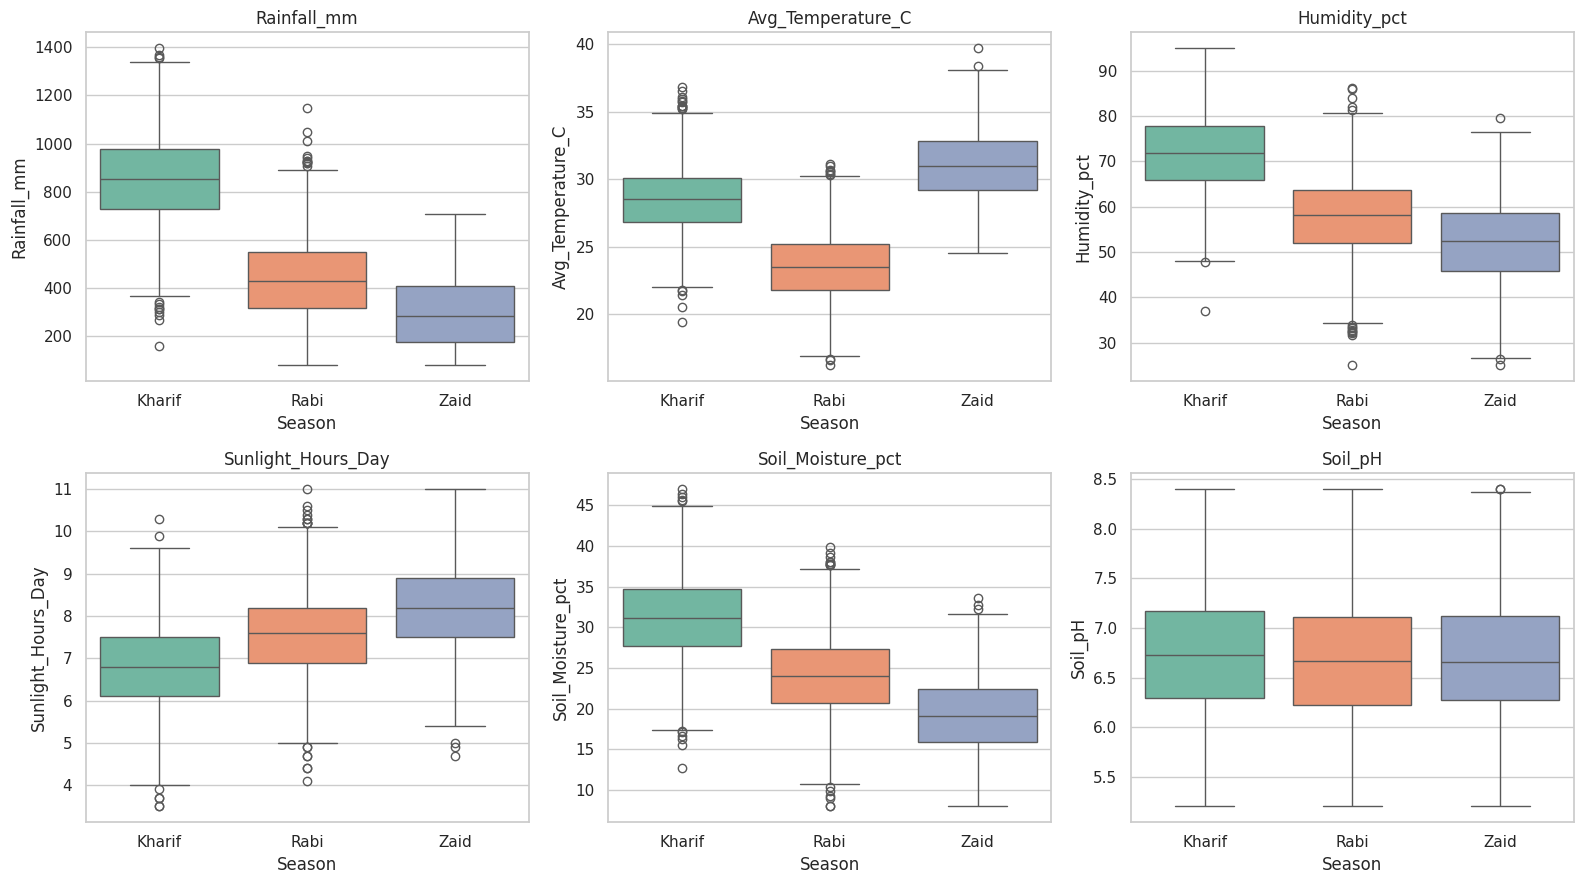

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, env_cols):
    sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
plt.tight_layout()
plt.show()

        mean  median    std  count
Season                            
Kharif  5.63    1.95  14.39   1779
Rabi    5.09    1.66  12.83   1627
Zaid    4.64    1.45  11.27    594


/tmp/ipykernel_699/1956904440.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2")


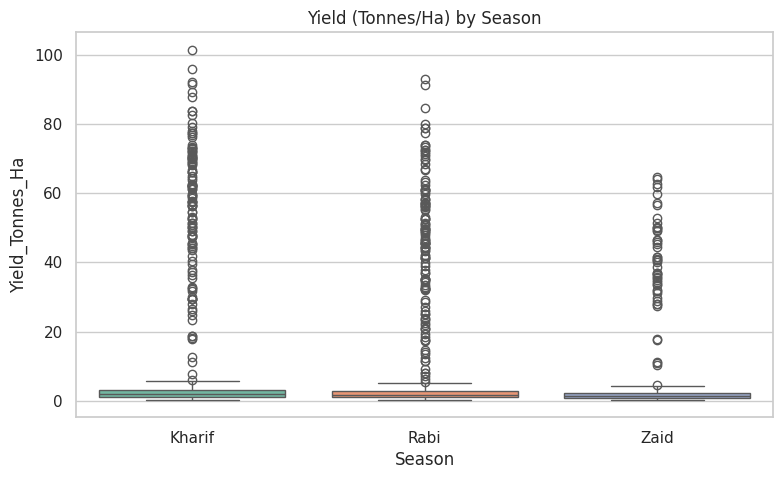

In [15]:
print(df.groupby("Season")["Yield_Tonnes_Ha"].agg(["mean", "median", "std", "count"]).round(2))

plt.figure()
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2")
plt.title("Yield (Tonnes/Ha) by Season")
plt.show()

In [16]:
groups = [df.loc[df["Season"] == s, "Yield_Tonnes_Ha"] for s in df["Season"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA on Yield across Seasons: F = {f_stat:.3f}, p = {p_val:.4f}")

ANOVA on Yield across Seasons: F = 1.458, p = 0.2328


In [17]:
econ_cols = ["Total_Cost_INR", "Revenue_INR", "Profit_INR", "Profit_per_Hectare", "Profit_Margin_pct"]
df.groupby("Season")[econ_cols].mean().round(1)

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_per_Hectare,Profit_Margin_pct
Season,,,,,
Kharif,531804.4,710719.1,178914.6,21881.8,-38.6
Rabi,513836.6,601526.0,87689.5,10361.7,-44.3
Zaid,543976.7,519171.9,-24804.8,-2636.5,-69.4


/tmp/ipykernel_699/906801525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Profit_INR", ax=axes[0], palette="Set2")
/tmp/ipykernel_699/906801525.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Season", y="Is_Profitable", ax=axes[1], palette="Set2",


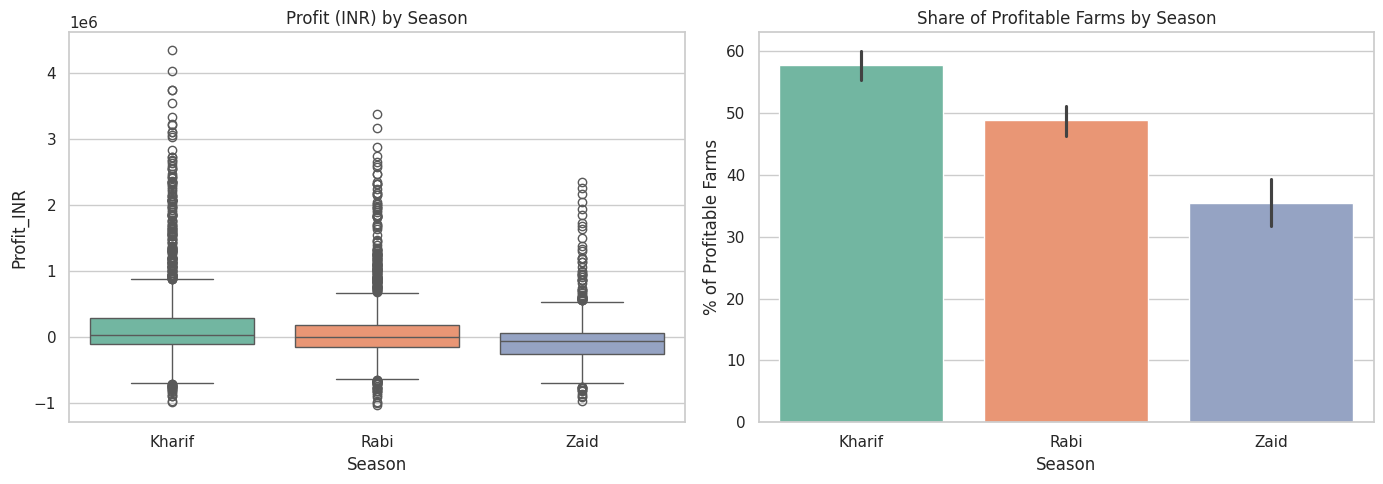

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR", ax=axes[0], palette="Set2")
axes[0].set_title("Profit (INR) by Season")
sns.barplot(data=df, x="Season", y="Is_Profitable", ax=axes[1], palette="Set2",
            estimator=lambda x: np.mean(x) * 100)
axes[1].set_ylabel("% of Profitable Farms")
axes[1].set_title("Share of Profitable Farms by Season")
plt.tight_layout()
plt.show()

In [19]:
groups_p = [df.loc[df["Season"] == s, "Profit_INR"] for s in df["Season"].unique()]
f_stat_p, p_val_p = stats.f_oneway(*groups_p)
print(f"ANOVA on Profit across Seasons: F = {f_stat_p:.3f}, p = {p_val_p:.4f}")

ANOVA on Profit across Seasons: F = 34.292, p = 0.0000


        Water_Used_m3  Water_Efficiency_t_per_1000m3  Fertilizer_kg_ha  \
Season                                                                   
Kharif        6102.20                           5.89            187.08   
Rabi          5846.99                           5.19            185.41   
Zaid          6419.89                           4.41            184.64   

        Pesticide_Litre_ha  
Season                      
Kharif                5.08  
Rabi                  5.02  
Zaid                  5.17  


/tmp/ipykernel_699/4141886844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set3")
/tmp/ipykernel_699/4141886844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set3")
/tmp/ipykernel_699/4141886844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set3")
/tmp/ipykernel_699/4141886844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

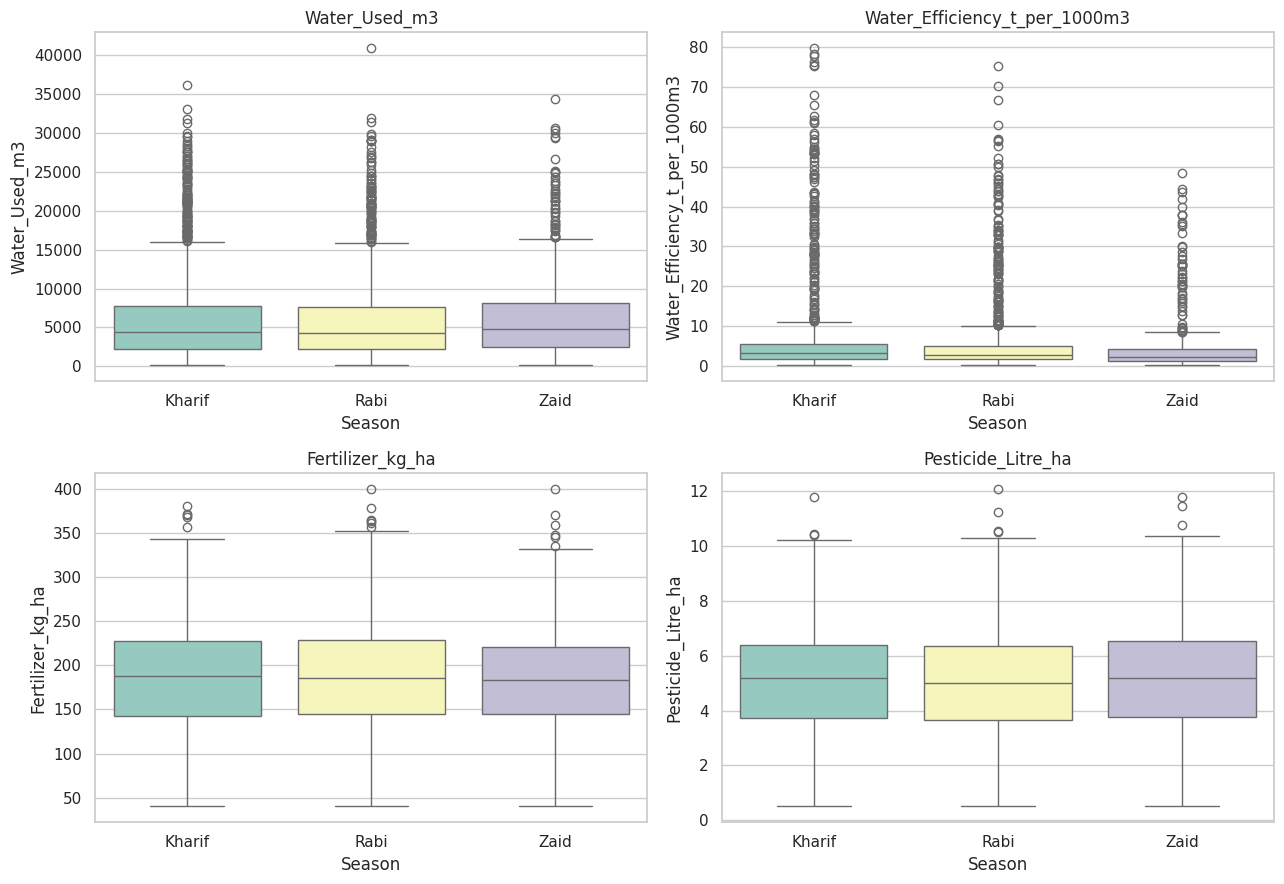

In [20]:
resource_cols = ["Water_Used_m3", "Water_Efficiency_t_per_1000m3", "Fertilizer_kg_ha", "Pesticide_Litre_ha"]
print(df.groupby("Season")[resource_cols].mean().round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, resource_cols):
    sns.boxplot(data=df, x="Season", y=col, ax=ax, palette="Set3")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             22.8   33.2     26.0       18.0
Rabi               22.7   32.3     26.9       18.0
Zaid               23.6   32.7     23.6       20.2


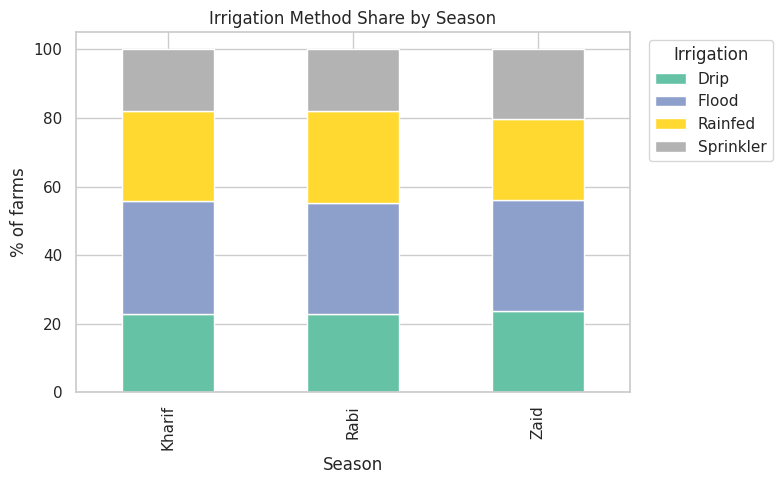

In [21]:
irrigation_season = pd.crosstab(df["Season"], df["Irrigation_Method"], normalize="index") * 100
print(irrigation_season.round(1))

irrigation_season.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.ylabel("% of farms")
plt.title("Irrigation Method Share by Season")
plt.legend(title="Irrigation", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

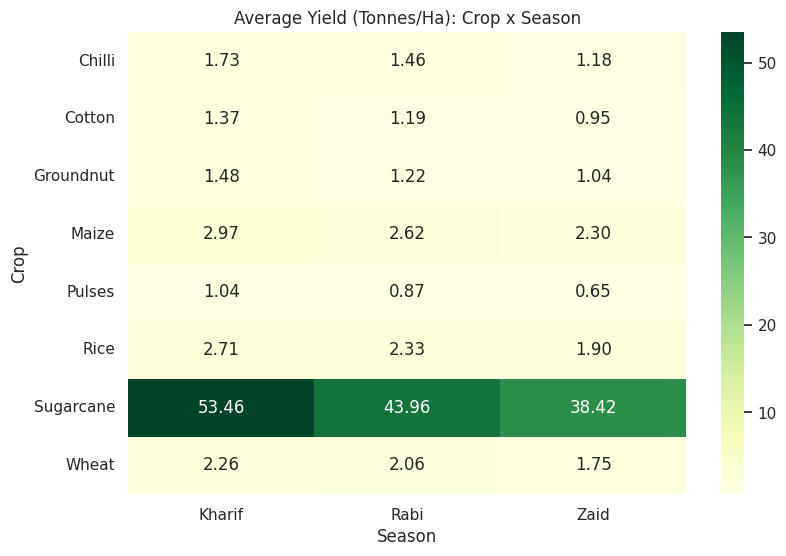

In [22]:
crop_season_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean").round(2)
plt.figure(figsize=(9, 6))
sns.heatmap(crop_season_yield, annot=True, cmap="YlGn", fmt=".2f")
plt.title("Average Yield (Tonnes/Ha): Crop x Season")
plt.show()

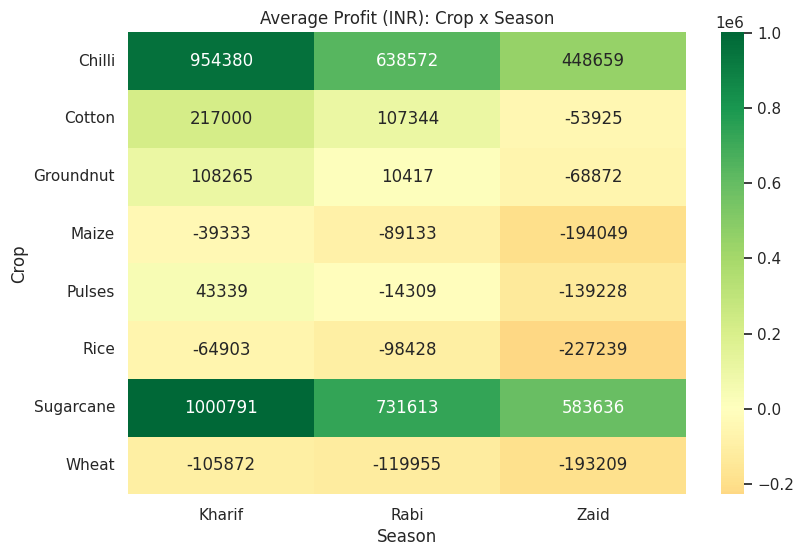

In [23]:
crop_season_profit = df.pivot_table(values="Profit_INR", index="Crop", columns="Season", aggfunc="mean").round(0)
plt.figure(figsize=(9, 6))
sns.heatmap(crop_season_profit, annot=True, cmap="RdYlGn", fmt=".0f", center=0)
plt.title("Average Profit (INR): Crop x Season")
plt.show()

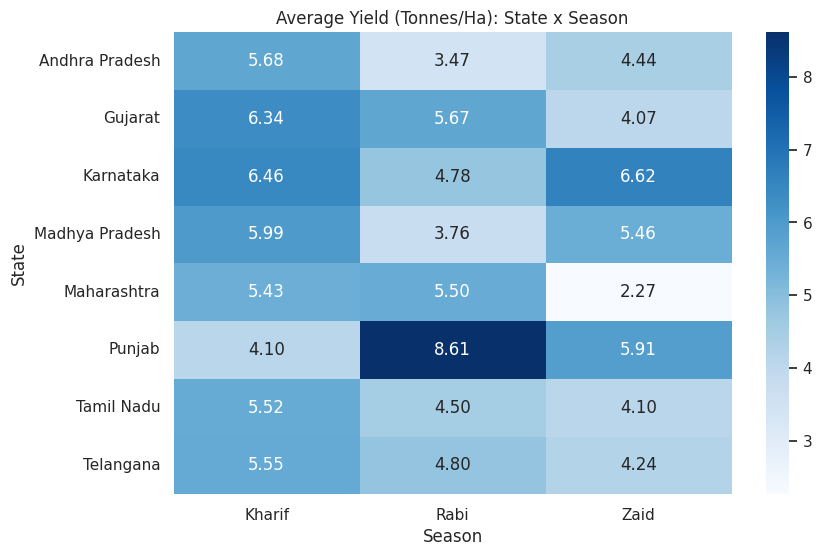

In [24]:
state_season_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="State", columns="Season", aggfunc="mean").round(2)
plt.figure(figsize=(9, 6))
sns.heatmap(state_season_yield, annot=True, cmap="Blues", fmt=".2f")
plt.title("Average Yield (Tonnes/Ha): State x Season")
plt.show()

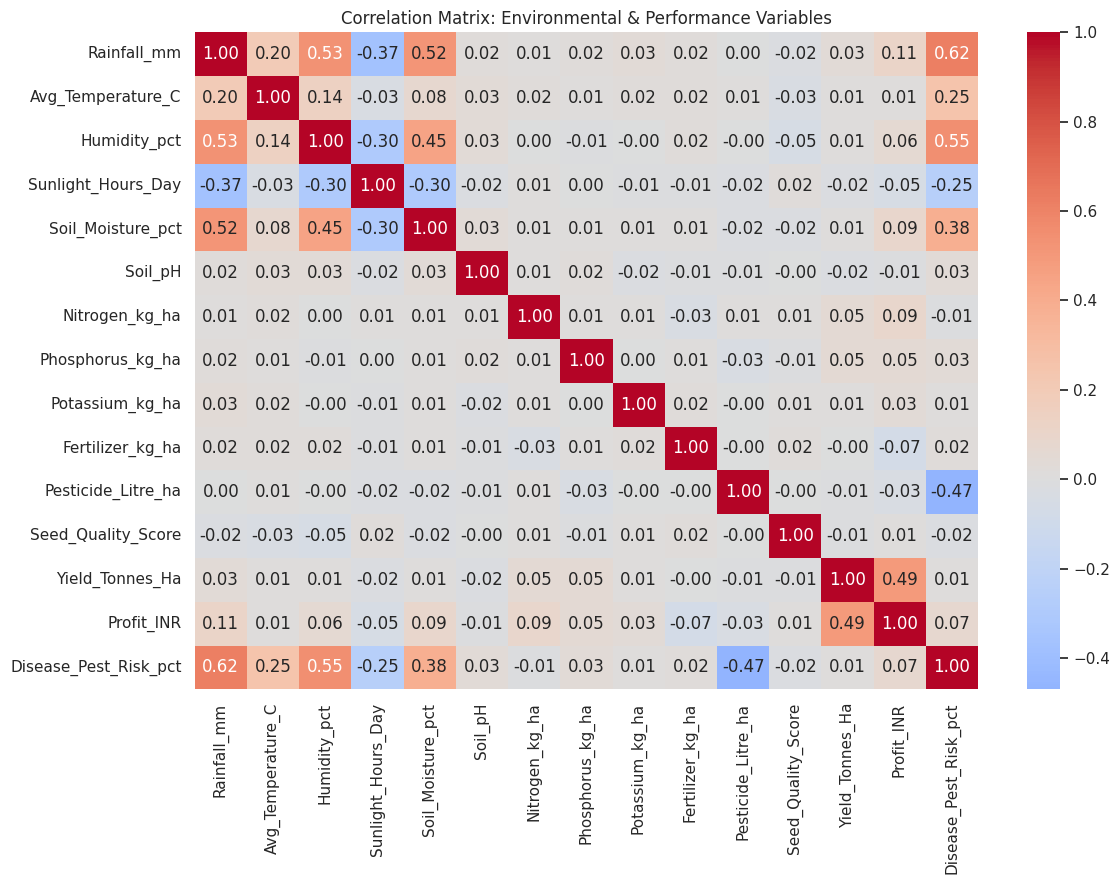

Yield_Tonnes_Ha          1.00
Profit_INR               0.49
Nitrogen_kg_ha           0.05
Phosphorus_kg_ha         0.05
Rainfall_mm              0.03
Humidity_pct             0.01
Avg_Temperature_C        0.01
Disease_Pest_Risk_pct    0.01
Potassium_kg_ha          0.01
Soil_Moisture_pct        0.01
Fertilizer_kg_ha        -0.00
Pesticide_Litre_ha      -0.01
Seed_Quality_Score      -0.01
Soil_pH                 -0.02
Sunlight_Hours_Day      -0.02
Name: Yield_Tonnes_Ha, dtype: float64


In [25]:
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Sunlight_Hours_Day",
             "Soil_Moisture_pct", "Soil_pH", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
             "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
             "Seed_Quality_Score", "Yield_Tonnes_Ha", "Profit_INR", "Disease_Pest_Risk_pct"]
corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix: Environmental & Performance Variables")
plt.tight_layout()
plt.show()

print(corr_matrix["Yield_Tonnes_Ha"].sort_values(ascending=False))

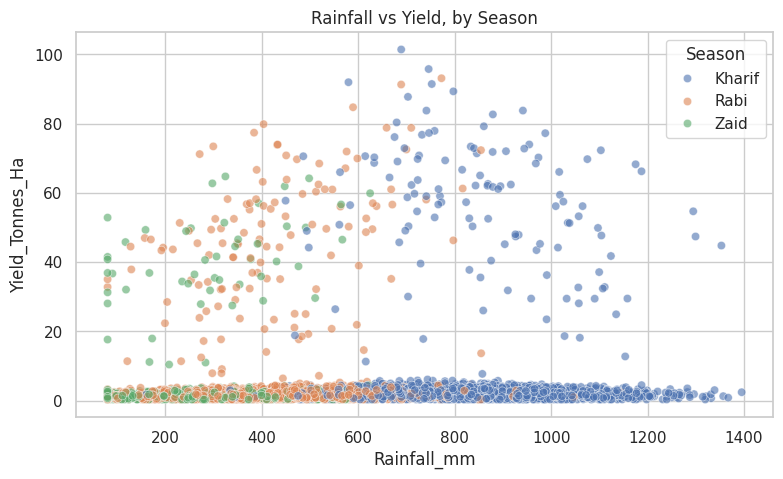

In [26]:
plt.figure()
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6)
plt.title("Rainfall vs Yield, by Season")
plt.show()

/tmp/ipykernel_699/2254293035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", palette="Set2")


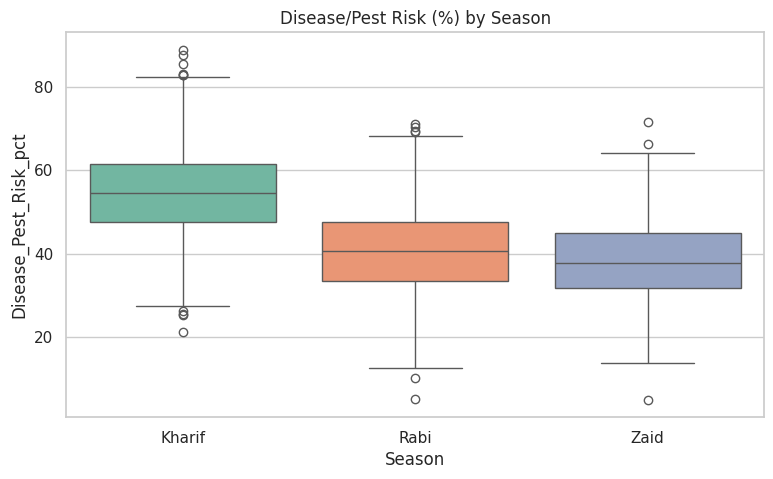

In [27]:
plt.figure()
sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", palette="Set2")
plt.title("Disease/Pest Risk (%) by Season")
plt.show()

In [28]:
low_yield_high_input = df[
    (df["Yield_Tonnes_Ha"] < df["Yield_Tonnes_Ha"].quantile(0.25))
    & (df["Fertilizer_kg_ha"] > df["Fertilizer_kg_ha"].quantile(0.75))
]
print(f"High fertilizer, low yield farms: {len(low_yield_high_input)} "
      f"({len(low_yield_high_input)/len(df)*100:.1f}% of farms)")
low_yield_high_input.groupby("Season").size()

High fertilizer, low yield farms: 233 (5.8% of farms)


,0
Season,
Kharif,81
Rabi,107
Zaid,45


In [29]:
summary = df.groupby("Season").agg(
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Temperature_C=("Avg_Temperature_C", "mean"),
    Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Cost_per_Ha=("Cost_per_Hectare", "mean"),
    Avg_Profit_per_Ha=("Profit_per_Hectare", "mean"),
    Pct_Profitable=("Is_Profitable", lambda x: x.mean() * 100),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
).round(2)
summary

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_t_ha,Avg_Cost_per_Ha,Avg_Profit_per_Ha,Pct_Profitable,Avg_Water_Used_m3,Avg_Disease_Risk_pct
Season,,,,,,,,
Kharif,852.10,28.45,5.63,66900.98,21881.81,57.79,6102.20,54.47
Rabi,435.95,23.49,5.09,66295.24,10361.68,48.86,5846.99,40.48
Zaid,299.16,31.04,4.64,66937.94,-2636.52,35.52,6419.89,38.22


# New Section